# Social Sentiment Analysis — phase two

Classify social posts as negative, neutral, or positive against human labels.

TweetEval’s SemEval-2017 sentiment task supplies 59,899 human-labelled posts. The original test split retains all 12,284 posts. Text-only overlap removal protects it from training contamination; ambiguous training labels and repeated training text are excluded. The upstream dataset licence is unspecified, so raw posts and error text stay local.

This notebook executes the same standalone implementation; original notebooks are preserved.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image, Markdown
from phase2 import run
summary = run()
summary

sentiment: tweet_tfidf; accuracy=0.5817; macro F1=0.5587; elapsed=17.21s


{'project': 'sentiment',
 'input_file': 'tweets.csv',
 'input_sha256': 'e5d6309c04d58786e17e2ffb057de81ca9e407af029581f503b8a861577c55b2',
 'rows_read': 59899,
 'rows_used': 59866,
 'earlier_rows_removed_for_overlap_or_ambiguity': 33,
 'test_rows_preserved': 12284,
 'test_duplicate_texts': 4,
 'selected_model': 'tweet_tfidf',
 'label_mapping': {0: 'negative', 1: 'neutral', 2: 'positive'},
 'selection': 'validation macro F1, log loss breaks ties',
 'splits': {'fit': {'rows': 34186,
   'class_counts': {0: 5318, 1: 15490, 2: 13378}},
  'calibration': {'rows': 11396, 'class_counts': {0: 1773, 1: 5163, 2: 4460}},
  'validation': {'rows': 2000, 'class_counts': {0: 312, 1: 869, 2: 819}},
  'test': {'rows': 12284, 'class_counts': {0: 3972, 1: 5937, 2: 2375}}},
 'test': {'model': 'tweet_tfidf',
  'split': 'test',
  'accuracy': 0.5817323347443829,
  'macro_f1': 0.5587443336650925,
  'macro_recall': 0.5651837162237557,
  'log_loss': 0.8963906160615154,
  'multiclass_brier': 0.5392936745531581},
 

In [2]:
display(pd.read_csv('results/phase2/metrics.csv'))

,model,split,accuracy,macro_f1,macro_recall,log_loss,multiclass_brier
0,prior_baseline,validation,0.434500,0.201929,0.333333,1.018427,0.619860
1,tweet_tfidf,validation,0.671500,0.626178,0.614403,0.751871,0.446183
2,tweet_tfidf_sigmoid,validation,0.667000,0.623553,0.614141,0.759199,0.450718
3,prior_baseline,test,0.483312,0.217222,0.333333,1.165652,0.692740
4,tweet_tfidf,test,0.581732,0.558744,0.565184,0.896391,0.539294
5,tweet_tfidf_sigmoid,test,0.590199,0.570136,0.572327,0.867325,0.524716
6,vader_rules,test,0.530039,0.528821,0.570007,NaN,NaN


In [3]:
display(Markdown(Path('results/phase2/REPORT.md').read_text()))

# Three-way social sentiment

Human-labelled TweetEval / SemEval-2017 social posts: negative, neutral, and positive.
All 12,284 official test rows are retained. Earlier-split overlaps are removed using text only;
33 earlier rows are excluded for overlap, duplication, or training-label ambiguity.
Training-only TF-IDF; an independent training reserve fits sigmoid calibration. Official validation selects the model.

**tweet_tfidf**: test accuracy 58.2%, macro F1 0.5587, macro recall 0.5652, log loss 0.8964.
VADER: accuracy 53.0%, macro F1 0.5288. Neutral is a genuine human-labelled class.

![Three-way confusion matrix](confusion.png)
![Top-class confidence calibration](reliability.png)

[Class support and Wilson intervals](class_intervals.json), [cluster bootstrap intervals](uncertainty.json),
[all metrics](metrics.csv), [validation stability](validation_stability.csv), [error source IDs](errors.csv),
and [review-to-tweet transfer](domain_shift.json) make results auditable.
[Diagnostic groups](diagnostic_groups.csv) use lexical heuristics; they cannot establish performance on human-labelled sarcasm or mixed sentiment.

This is historical general social sentiment, not a Black Friday survey. Authored examples are illustrations.
TweetEval's dataset licence is unspecified. Raw posts and error text remain local; the repository publishes hashes,
source row IDs, derived results, and a verified downloader. Models, calibration, and splits never tune on test labels.
This is a benchmark, with unknown author/topic/time overlap and no newly collected external validation.


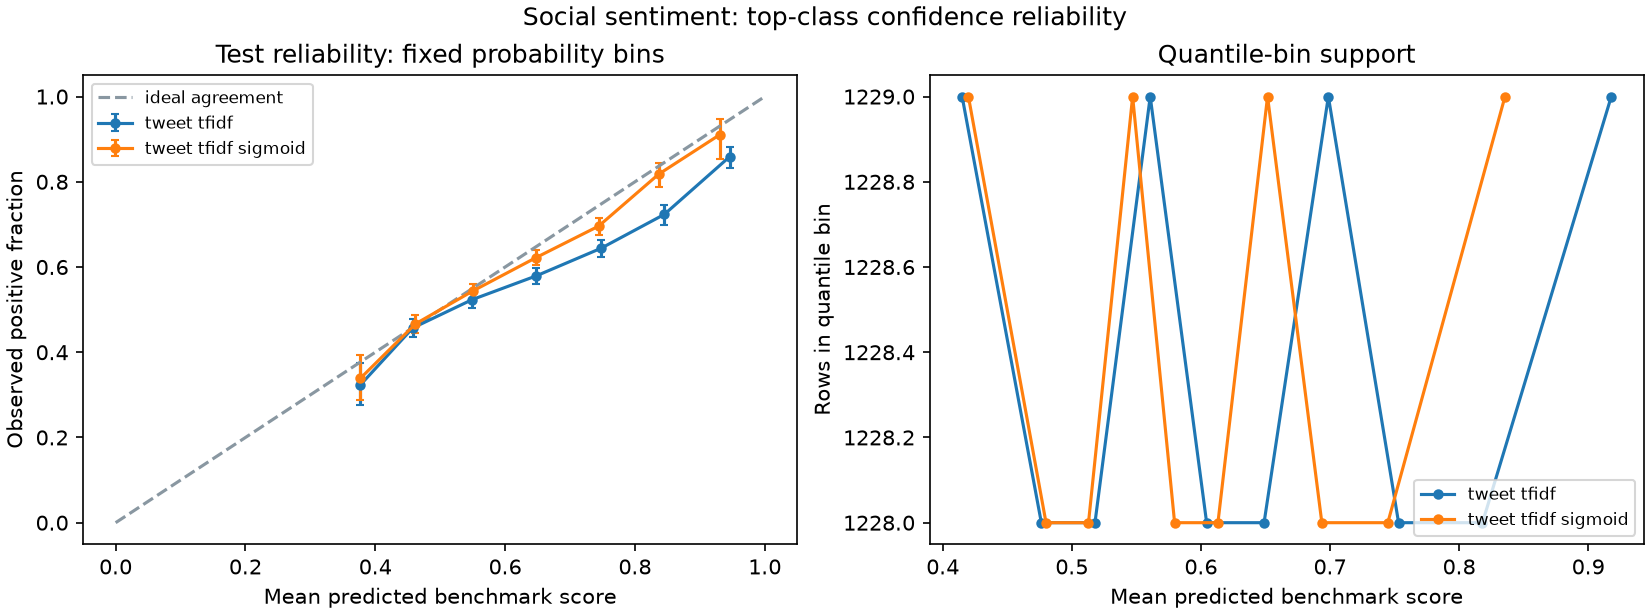

,seed,accuracy,macro_f1,macro_recall,log_loss,multiclass_brier
0,43,0.654828,0.608764,0.593860,0.753418,0.452852
1,44,0.660607,0.609100,0.593444,0.751352,0.451412
2,45,0.655038,0.608426,0.592017,0.757900,0.455453


In [4]:
display(Image(filename='results/phase2/reliability.png'))
display(pd.read_csv('results/phase2/validation_stability.csv'))

In [5]:
json.loads(Path('results/phase2/uncertainty.json').read_text())

{'replicates': 200,
 'method': 'Cluster bootstrap of identical normalized test text',
 'intervals': {'accuracy': {'low': 0.5742055453755763,
   'high': 0.5897802220996881},
  'macro_f1': {'low': 0.5492009647924935, 'high': 0.5681296872225645},
  'macro_recall': {'low': 0.5569827238441353, 'high': 0.5740090094061505},
  'log_loss': {'low': 0.8845307878343488, 'high': 0.9068867335423679},
  'multiclass_brier': {'low': 0.5312868797892869, 'high': 0.5461277461006555}}}

In [6]:
display(pd.read_csv('results/phase2/errors.csv').head(10))

,source_id,negative_score,neutral_score,positive_score,predicted_label,predicted_sentiment,text_sha256,actual,vader_label
0,test:0,0.660712,0.326573,0.012714,0,negative,6c28df8b37da4b318e8ad24bda726da72c0df8b332a44b...,1,0
1,test:2,0.365825,0.318056,0.316119,0,negative,c6eca21f39338b1e571f37ef56a58396543556e525af2b...,1,0
2,test:4,0.163160,0.462430,0.374409,1,neutral,048d4ca0dbe5595aaa2a0d48df4ca7762cb96ce22c59db...,0,2
3,test:5,0.607873,0.347996,0.044131,0,negative,54dfba37e145c8225fccc12f7e8c0c8780248ae06b02f8...,1,1
4,test:7,0.269170,0.610953,0.119877,1,neutral,cb2d04130b290d3fb429627fd5dfbf2879f739f7c5c0f3...,2,2
5,test:10,0.327012,0.141960,0.531028,2,positive,bf34b3317120c0433d61c8b1dc8462b4be58241d6f512d...,1,0
6,test:13,0.301861,0.588395,0.109744,1,neutral,0d0b1e1419fdef104246937dbde48ecd6c50d112ce71b1...,0,1
7,test:14,0.337938,0.171526,0.490537,2,positive,be48360e01f4b3dee9b1323fa2360e17c24cdcfe5b2918...,0,0
8,test:19,0.132413,0.405298,0.462289,2,positive,c12bbaaa04976c4bea272a86e9c67cfa165e5fe32114c8...,1,1
9,test:24,0.046539,0.440649,0.512811,2,positive,cdc4ca7420dce5cbaaa111ba0fa21581ec49ff8be7ecdb...,1,2


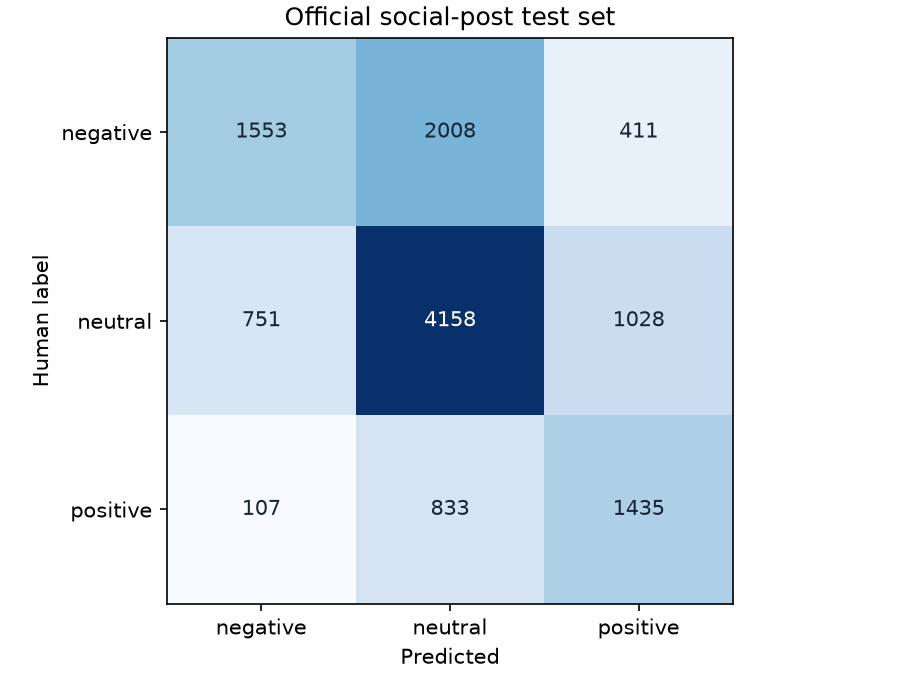

{'review_model_uci_accuracy': 0.7953020134228188,
 'review_model_binary_tweet_accuracy': 0.65574287064755,
 'binary_tweet_rows': 6347,
 'neutral_rows_excluded': 5937,
 'interpretation': 'Different class prevalence and datasets; this is a transfer diagnostic, not a controlled causal estimate of domain shift.'}

In [7]:
display(Image(filename='results/phase2/confusion.png'))
display(json.loads(Path('results/phase2/domain_shift.json').read_text()))

## Interpretation

The three-way model is compared with a prior baseline and VADER. A separate diagnostic measures the old review model on binary-labelled tweets. The different datasets, classes, and prevalences mean that 58% social accuracy cannot be compared directly with 79.5% binary-review accuracy. Lexical negation, contrast, and sarcasm hints support inspection; they are not human annotations of those properties.

Use `python predict_tweets.py --data examples/black_friday_posts.csv`. These examples are authored illustrations. Reconstruct local error text by source ID after fetching the pinned TweetEval files. This project measures general historical social sentiment, rather than Black Friday public opinion.